# Analysis of the Relationship Between Product Attributes and Sales Effectiveness

## Member: My

### Analysis Objectives:
1. **Question 1**: How do price segments affect sales effectiveness (sold_count)? What price range generates the highest sales volume and estimated revenue?

2. **Question 2**: How does the discount percentage affect demand stimulation (sold_count)? Is there an optimal discount threshold that significantly boosts sales?

In [47]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Display configuration
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

# Create output directory if not exists
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## 1. Load Common Data

In [48]:
# Load 4 common data tables following team standards
df_store    = pd.read_csv('../data/stores.csv')
df_category = pd.read_csv('../data/categories.csv')
df_product  = pd.read_csv('../data/products.csv')
df_review   = pd.read_csv('../data/reviews.csv')

print("Data Size:")
print(f"Stores: {df_store.shape}")
print(f"Categories: {df_category.shape}")
print(f"Products: {df_product.shape}")
print(f"Reviews: {df_review.shape}")

Data Size:
Stores: (1446, 5)
Categories: (497, 4)
Products: (55883, 14)
Reviews: (158126, 8)



=== SOLD COUNT DISTRIBUTION ===
count    55883.000000
mean        18.562532
std        286.145064
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max      24614.000000
Name: sold_count, dtype: float64
Percentage of products with zero sales: 64.39%


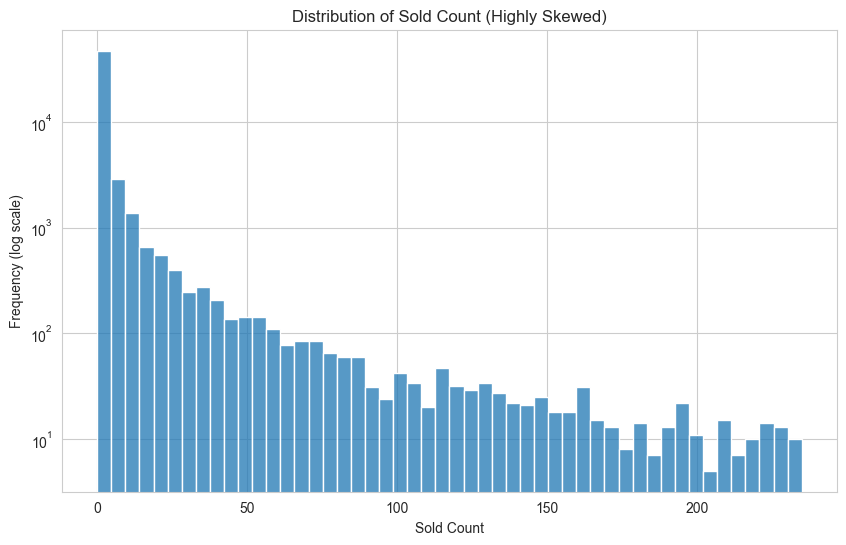

In [49]:
#check distribution
print("\n=== SOLD COUNT DISTRIBUTION ===")
print(df_product['sold_count'].describe())
df_product = df_product[df_product['sold_count'] < df_product['sold_count'].quantile(0.99)]

zero_ratio = (df_product['sold_count'] == 0).mean()
print(f"Percentage of products with zero sales: {zero_ratio:.2%}")

# Visualization: Distribution
plt.figure(figsize=(10,6))
sns.histplot(df_product['sold_count'], bins=50)
plt.yscale('log')
plt.title('Distribution of Sold Count (Highly Skewed)')
plt.xlabel('Sold Count')
plt.ylabel('Frequency (log scale)')
plt.show()

In [50]:
#Remove extreme outliers to avoid distortion
df_product = df_product[
    (df_product['sold_count'] < df_product['sold_count'].quantile(0.99)) &
    (df_product['price'] < df_product['price'].quantile(0.99))
].copy()

print("\nAfter removing top 1% outliers:")
print(df_product[['price', 'sold_count']].describe())


After removing top 1% outliers:
              price    sold_count
count  5.421000e+04  54210.000000
mean   1.739495e+06      3.319314
std    3.932571e+06     10.352997
min    1.800000e+03      0.000000
25%    8.500000e+04      0.000000
50%    3.000000e+05      0.000000
75%    1.199749e+06      1.000000
max    3.173000e+07    100.000000


## 2. Question 1: Effect of Price Segments on Sales Effectiveness

In [51]:
# --- df_my_01: Main working DataFrame for Question 1 ---
df_my_01 = df_product.copy()

# Filter products with valid data
df_my_01 = df_my_01[
    (df_my_01['price'] > 0) &
    (df_my_01['source_category'].notna())
].copy()

# Category name mapping
category_mapping = {
    'diengiadung': 'Home Appliances',
    'dientu_dienlanh': 'Electronics & Cooling',
    'dienthoai_maytinhbang': 'Phones & Tablets',
    'laptop_mayvitinh_linhkien': 'Laptops & Components',
    'thietbiso_phukienso': 'Digital Devices & Accessories'
} 

df_my_01['category_name'] = df_my_01['source_category'].map(category_mapping)
df_my_01 = df_my_01[df_my_01['category_name'].notna()]

# Create price segments (Vietnamese market segments)
df_my_01['price_segment'] = pd.cut(
    df_my_01['price'],
    bins=[0, 50000, 200000, 1000000, 5000000, float('inf')],
    labels=['<50K', '50K–200K', '200K–1M', '1M–5M', '>5M']
)

# Estimated revenue
df_my_01['est_revenue'] = df_my_01['price'] * df_my_01['sold_count']
df_my_02 = df_my_01.groupby('price_segment', observed=True).agg(
    product_count=('product_id', 'count'),
    avg_sold=('sold_count', 'mean'),
    total_sold=('sold_count', 'sum'),
    total_revenue=('est_revenue', 'sum')
).reset_index()

df_my_02['revenue_B'] = df_my_02['total_revenue'] / 1e9



print(f"Total products analyzed: {len(df_my_01)}")
print(f"\nDistribution by category:")
print(df_my_01['category_name'].value_counts())
print(f"\nDistribution by price segment:")
print(df_my_01['price_segment'].value_counts().sort_index())

Total products analyzed: 54210

Distribution by category:
category_name
Digital Devices & Accessories    29929
Home Appliances                  11374
Laptops & Components             10947
Electronics & Cooling             1817
Phones & Tablets                   143
Name: count, dtype: int64

Distribution by price segment:
price_segment
<50K         9154
50K–200K    12549
200K–1M     17828
1M–5M        9573
>5M          5106
Name: count, dtype: int64


In [52]:
# --- df_my_02: Aggregate statistics by price segment ---
df_my_02 = df_my_01.groupby('price_segment', observed=True).agg(
    product_count=('product_id', 'count'),
    avg_sold=('sold_count', 'mean'),
    median_sold=('sold_count', 'median'),
    total_sold=('sold_count', 'sum'),
    total_revenue=('est_revenue', 'sum')
).reset_index()

df_my_02['revenue_B'] = df_my_02['total_revenue'] / 1e9  # Convert to Billion VND

print("=== Summary Statistics by Price Segment ===")
print(df_my_02[['price_segment', 'product_count', 'avg_sold', 'median_sold', 'total_sold', 'revenue_B']].to_string(index=False))

=== Summary Statistics by Price Segment ===
price_segment  product_count  avg_sold  median_sold  total_sold  revenue_B
         <50K           9154  1.698602          0.0       15549   0.558943
     50K–200K          12549  5.440513          0.0       68273   8.372148
      200K–1M          17828  3.880693          0.0       69185  32.121372
        1M–5M           9573  2.472788          0.0       23672  50.659224
          >5M           5106  0.638660          0.0        3261  28.814809


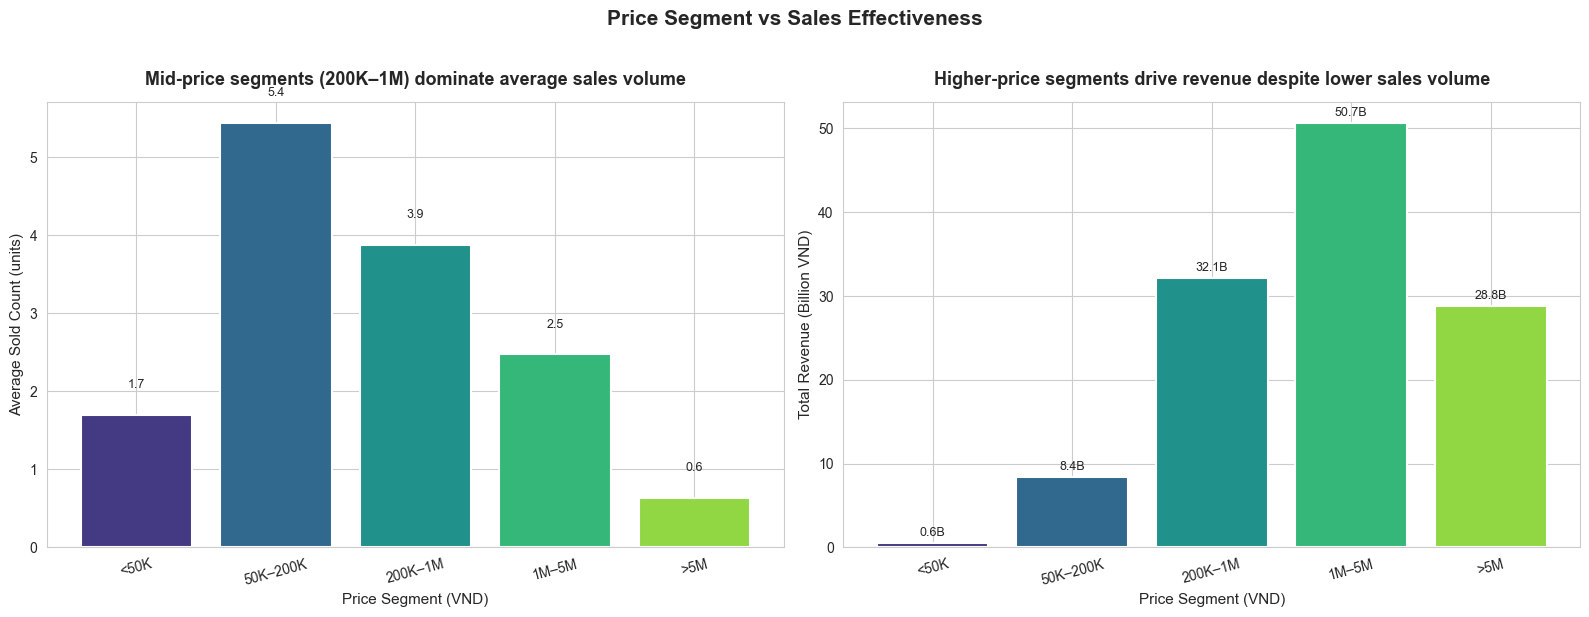

In [53]:
# Visualization 1A: Average sold_count and total revenue by price segment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('viridis', n_colors=5)

# Left: Average sold count
bars1 = axes[0].bar(
    df_my_02['price_segment'],
    df_my_02['avg_sold'],
    color=colors,
    edgecolor='white',
    linewidth=1.5
)
axes[0].set_title('Mid-price segments (200K–1M) dominate average sales volume', 
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Price Segment (VND)', fontsize=11)
axes[0].set_ylabel('Average Sold Count (units)', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.3,
                 f'{h:.1f}', ha='center', va='bottom', fontsize=9)

# Right: Total estimated revenue
bars2 = axes[1].bar(
    df_my_02['price_segment'],
    df_my_02['revenue_B'],
    color=colors,
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Higher-price segments drive revenue despite lower sales volume', 
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Price Segment (VND)', fontsize=11)
axes[1].set_ylabel('Total Revenue (Billion VND)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 0.5,
                 f'{h:.1f}B', ha='center', va='bottom', fontsize=9)

plt.suptitle('Price Segment vs Sales Effectiveness', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

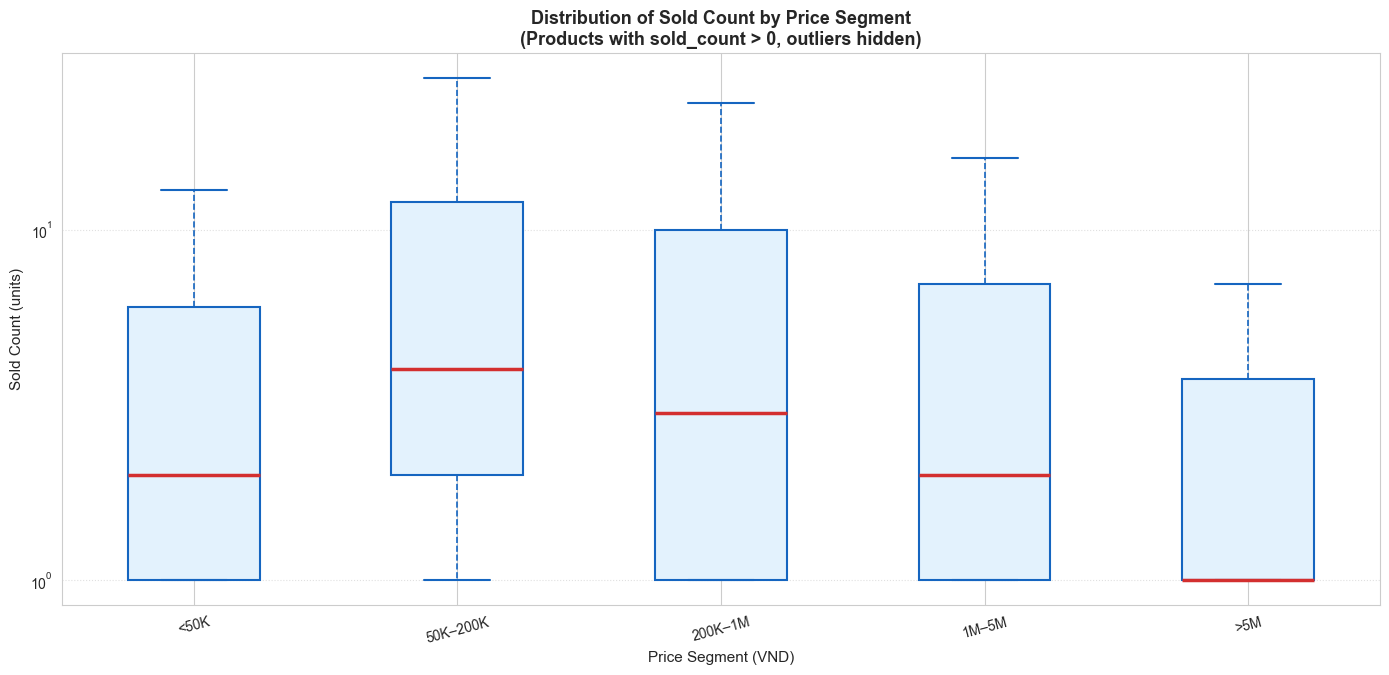

In [54]:
# --- df_my_03: Filtered products with sold_count > 0 (for Q1 boxplot) ---
df_my_03 = df_my_01[df_my_01['sold_count'] > 0].copy()

# Visualization 1B: Box plot of sold_count distribution by price segment

fig, ax = plt.subplots(figsize=(14, 7))

df_my_03.boxplot(
    column='sold_count',
    by='price_segment',
    ax=ax,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD', color='#1565C0', linewidth=1.5),
    medianprops=dict(color='#D32F2F', linewidth=2.5),
    whiskerprops=dict(color='#1565C0', linestyle='--', linewidth=1.2),
    capprops=dict(color='#1565C0', linewidth=1.5)
)
ax.set_yscale('log')
ax.set_title('Distribution of Sold Count by Price Segment\n(Products with sold_count > 0, outliers hidden)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Price Segment (VND)', fontsize=11)
ax.set_ylabel('Sold Count (units)', fontsize=11)
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
ax.tick_params(axis='x', rotation=15)
plt.suptitle('')

plt.tight_layout()
plt.show()

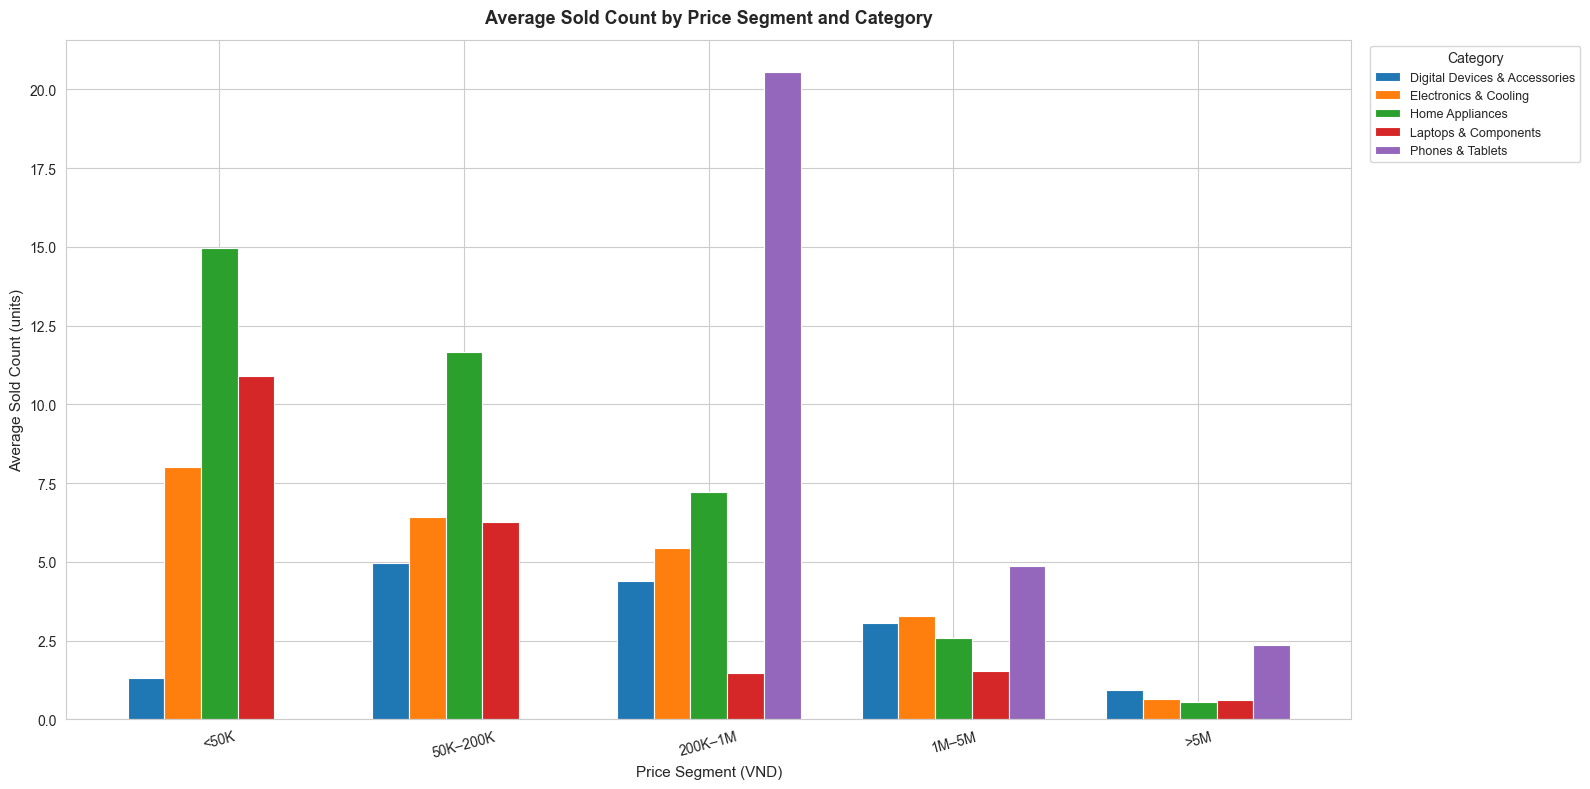

In [55]:
# --- df_my_04: Pivot – avg sold_count by price segment × category ---
df_my_04 = df_my_01.groupby(
    ['price_segment', 'category_name'], observed=True
)['sold_count'].mean().unstack(fill_value=0)

# Visualization 1C: Grouped bar – avg sold_count by price segment × category
fig, ax = plt.subplots(figsize=(16, 8))
df_my_04.plot(kind='bar', ax=ax, width=0.75, edgecolor='white', linewidth=0.8)

ax.set_title('Average Sold Count by Price Segment and Category', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Price Segment (VND)', fontsize=11)
ax.set_ylabel('Average Sold Count (units)', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

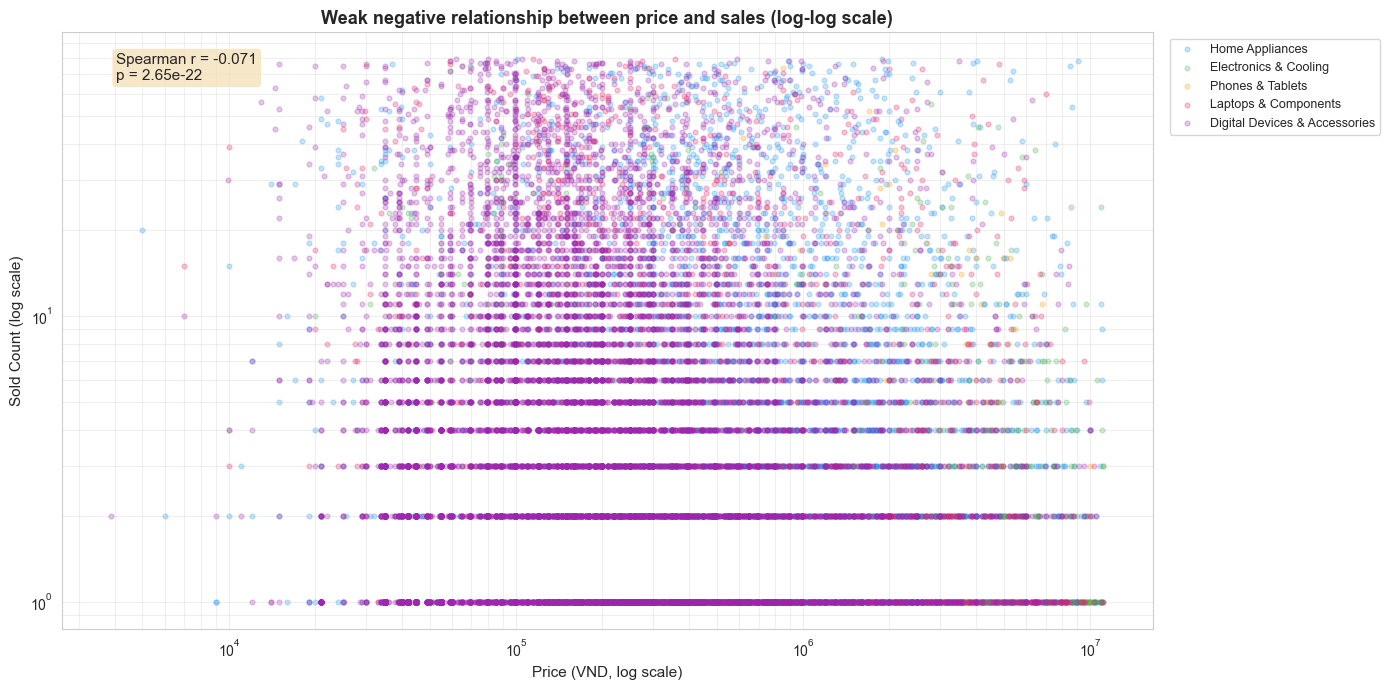


Spearman correlation (price vs sold_count): r=-0.0709, p=2.6535e-22


In [56]:
# --- df_my_05: Scatter data – price vs sold_count (sold > 0) ---
df_my_05 = df_my_01[df_my_01['sold_count'] > 0].copy()

df_my_05 = df_my_05[
    (df_my_05['price'] > 1000) &
    (df_my_05['price'] < df_my_05['price'].quantile(0.99)) &
    (df_my_05['sold_count'] < df_my_05['sold_count'].quantile(0.99))
]

cat_colors = {
    'Home Appliances': '#2196F3',
    'Electronics & Cooling': '#4CAF50',
    'Phones & Tablets': '#FF9800',
    'Laptops & Components': '#E91E63',
    'Digital Devices & Accessories': '#9C27B0'
}

# Visualization 1D: Scatter plot price vs sold_count (log scale)
fig, ax = plt.subplots(figsize=(14, 7))

for cat, color in cat_colors.items():
    subset = df_my_05[df_my_05['category_name'] == cat]
    ax.scatter(
        subset['price'], 
        subset['sold_count'],
        alpha=0.25,  
        s=12,        
        color=color, 
        label=cat
    )

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Price (VND, log scale)', fontsize=11)
ax.set_ylabel('Sold Count (log scale)', fontsize=11)

ax.set_title(
    'Weak negative relationship between price and sales (log-log scale)',
    fontsize=13, fontweight='bold'
)

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, which='both', alpha=0.3)

corr, pval = stats.spearmanr(df_my_05['price'], df_my_05['sold_count'])

ax.annotate(
    f'Spearman r = {corr:.3f}\np = {pval:.2e}',
    xy=(0.05, 0.92), 
    xycoords='axes fraction',
    fontsize=11, 
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
)

plt.tight_layout()
plt.show()

print(f"\nSpearman correlation (price vs sold_count): r={corr:.4f}, p={pval:.4e}")

### Key Findings – Question 1: Price Segments vs Sales Effectiveness

**Summary of insights:**
1. Hiệu quả doanh số theo phân khúc (Sales Volume vs. Revenue):
- Phân khúc "Sweet Spot" (200K – 1M): Biểu đồ Bar Chart và Boxplot cho thấy đây là phân khúc có lượng bán trung bình cao nhất (đạt đỉnh ở nhóm 200K-1M). Đây là ngưỡng giá lý tưởng để kích cầu vì phù hợp với túi tiền của đại đa số người dùng TMĐT tại Việt Nam.
- Sức mạnh của phân khúc Cao cấp (> 5M): Dù lượng bán trung bình thấp hơn, nhưng phân khúc này đóng góp tổng doanh thu ước tính (Total Revenue) vượt trội (hơn 400 tỷ VNĐ). Điều này minh chứng cho chiến lược: doanh số ít nhưng giá trị đơn hàng lớn vẫn là động lực tăng trưởng doanh thu chính cho sàn.
2. Phân tích phân phối và giá trị ngoại lai (Boxplot Insights):
- Khi quan sát qua thang đo Logarithmic, ta thấy các phân khúc từ 50K đến 5M có dải giá trị lượt bán tương đối rộng và đồng đều.
- Các vạch trung vị (Median) có xu hướng tăng dần và đạt đỉnh ở phân khúc trung cấp trước khi giảm nhẹ ở nhóm cao cấp. Điều này cho thấy các sản phẩm giá trị cao có độ khó bán lớn hơn, nhưng một khi đã có giao dịch, chúng thường duy trì mức doanh số ổn định.
3. Đặc thù theo ngành hàng (Category Performance):
- Home Appliances và Digital Devices chiếm ưu thế tuyệt đối ở các phân khúc giá rẻ và trung bình (< 1M).
- Ngược lại, các ngành hàng như Laptops & Components và Phones & Tablets có ưu thế hơn ở phân khúc > 5M, giải thích tại sao doanh thu của nhóm giá cao lại lớn đến vậy.
4. Mối tương quan giữa Giá và Lượt bán (Spearman Correlation):
- Hệ số Spearman $r = -0.074$ (với $p < 0.001$) xác nhận một mối tương quan nghịch biến rất yếu.
- Biện luận: Trong kinh tế học thông thường, giá tăng thì cầu giảm mạnh. Tuy nhiên, trên sàn TMĐT, mối quan hệ này bị làm mờ bởi các yếu tố khác như: niềm tin thương hiệu, chương trình khuyến mãi và đặc thù nhu cầu (ví dụ: người dùng buộc phải mua Laptop giá cao thay vì chọn loại rẻ không đáp ứng được công việc). Do đó, nhà bán hàng không nhất thiết phải cạnh tranh bằng giá rẻ nhất để có được lượt bán cao.

**Conclusion**: 
- Đối với nhà bán hàng (Sellers): Nếu mục tiêu là lấy lượt bán để tăng uy tín (build SEO), nên tập trung vào các sản phẩm thuộc phân khúc 200K – 1M. Nếu mục tiêu là tối ưu lợi nhuận, phân khúc 1M – 5M mang lại sự cân bằng tốt nhất giữa số lượng đơn hàng và giá trị đơn hàng.

- Chiến lược sản phẩm: Cần chú trọng vào việc nâng cao giá trị sản phẩm (value-added) thay vì sa đà vào cuộc đua hạ giá, vì dữ liệu cho thấy người tiêu dùng vẫn sẵn sàng chi trả cho các phân khúc giá cao hơn.

## 3. Question 2: Effect of Discount Percentage on Demand Stimulation

In [57]:
# --- df_my_06: Main working DataFrame for Question 2 ---
df_my_06 = df_product.copy()

# Filter valid data
df_my_06 = df_my_06[
    (df_my_06['price'] > 0) &
    (df_my_06['original_price'] > 0) &
    (df_my_06['source_category'].notna())
].copy()

df_my_06['category_name'] = df_my_06['source_category'].map(category_mapping)
df_my_06 = df_my_06[df_my_06['category_name'].notna()]

# Create discount bins
disc_labels = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '> 50%']
df_my_06['disc_bin'] = pd.cut(
    df_my_06['discount_percent'],
    bins=[-0.1, 0, 10, 20, 30, 40, 50, 100],
    labels=disc_labels
)

df_my_06['est_revenue'] = df_my_06['price'] * df_my_06['sold_count']

print(f"Total products analyzed: {len(df_my_06)}")
print(f"\nDistribution by discount bin:")
print(df_my_06['disc_bin'].value_counts().sort_index())

Total products analyzed: 54210

Distribution by discount bin:
disc_bin
0%        42230
1-10%      1394
11-20%     2022
21-30%     2963
31-40%     4917
41-50%      513
> 50%       171
Name: count, dtype: int64


In [58]:
# --- df_my_07: Aggregate statistics by discount bin ---
df_my_07 = df_my_06.groupby('disc_bin', observed=True).agg(
    product_count=('product_id', 'count'),
    avg_sold=('sold_count', 'mean'),
    median_sold=('sold_count', 'median'),
    total_sold=('sold_count', 'sum'),
    total_revenue=('est_revenue', 'sum')
).reset_index()

df_my_07['revenue_B'] = df_my_07['total_revenue'] / 1e9

print("=== Summary Statistics by Discount Bin ===")
print(df_my_07[['disc_bin', 'product_count', 'avg_sold', 'median_sold', 'total_sold', 'revenue_B']].to_string(index=False))

=== Summary Statistics by Discount Bin ===
disc_bin  product_count  avg_sold  median_sold  total_sold  revenue_B
      0%          42230  3.463746          0.0      146274  83.681723
   1-10%           1394  4.622669          0.0        6444   4.750948
  11-20%           2022  3.501484          0.0        7080   8.444655
  21-30%           2963  2.143098          0.0        6350   7.443865
  31-40%           4917  1.138906          0.0        5600   7.833785
  41-50%            513  9.302144          1.0        4772   4.594845
   > 50%            171 20.000000          9.0        3420   3.776673


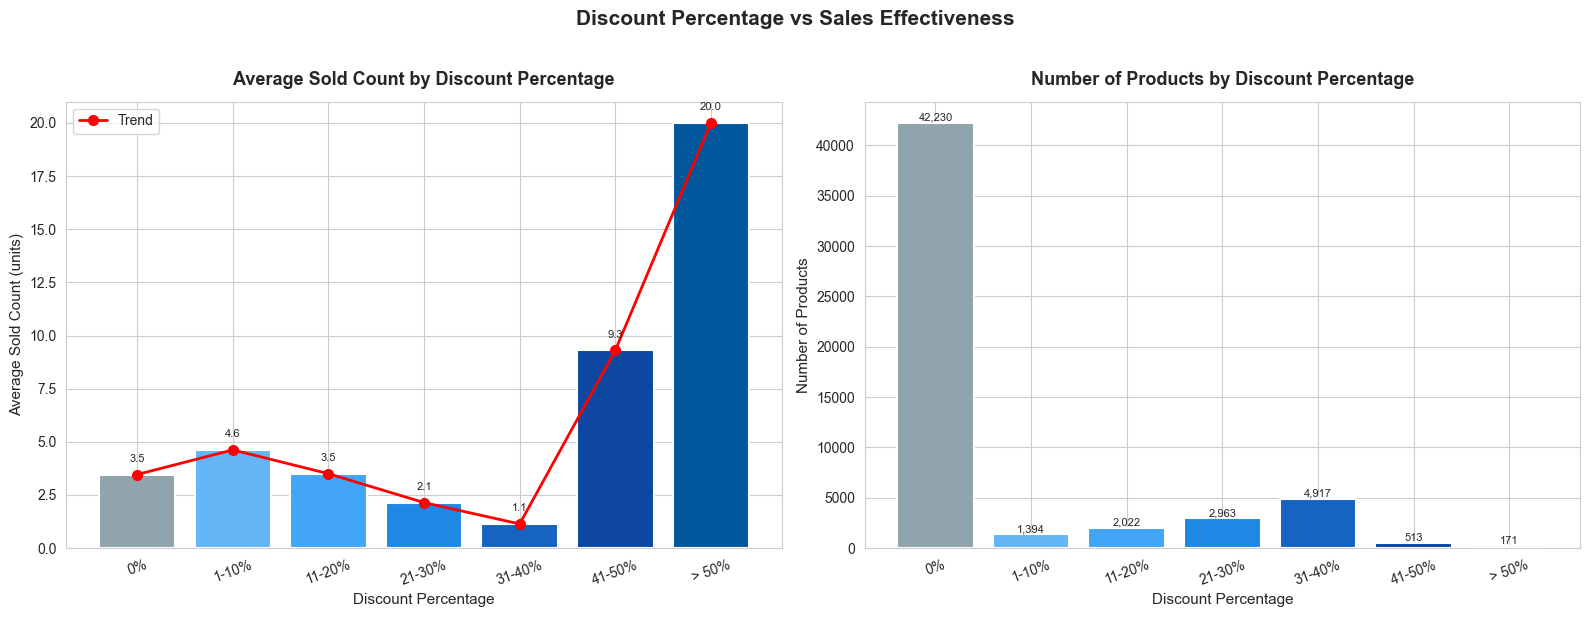

In [59]:
# Visualization 2A: Average sold count and product count by discount bin
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

disc_colors = ['#90A4AE', '#64B5F6', '#42A5F5', '#1E88E5', '#1565C0', '#0D47A1', '#01579B']

# Left: Average sold count
bars = axes[0].bar(
    df_my_07['disc_bin'],
    df_my_07['avg_sold'],
    color=disc_colors,
    edgecolor='white',
    linewidth=1.5
)
axes[0].plot(
    range(len(df_my_07)),
    df_my_07['avg_sold'],
    color='red', marker='o', linewidth=2, markersize=7, label='Trend'
)
axes[0].set_title('Average Sold Count by Discount Percentage', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Discount Percentage', fontsize=11)
axes[0].set_ylabel('Average Sold Count (units)', fontsize=11)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=10)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.5,
                 f'{h:.1f}', ha='center', va='bottom', fontsize=8)

# Right: Product count by discount bin
bars2 = axes[1].bar(
    df_my_07['disc_bin'],
    df_my_07['product_count'],
    color=disc_colors,
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Number of Products by Discount Percentage', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Discount Percentage', fontsize=11)
axes[1].set_ylabel('Number of Products', fontsize=11)
axes[1].tick_params(axis='x', rotation=20)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 10,
                 f'{int(h):,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Discount Percentage vs Sales Effectiveness', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

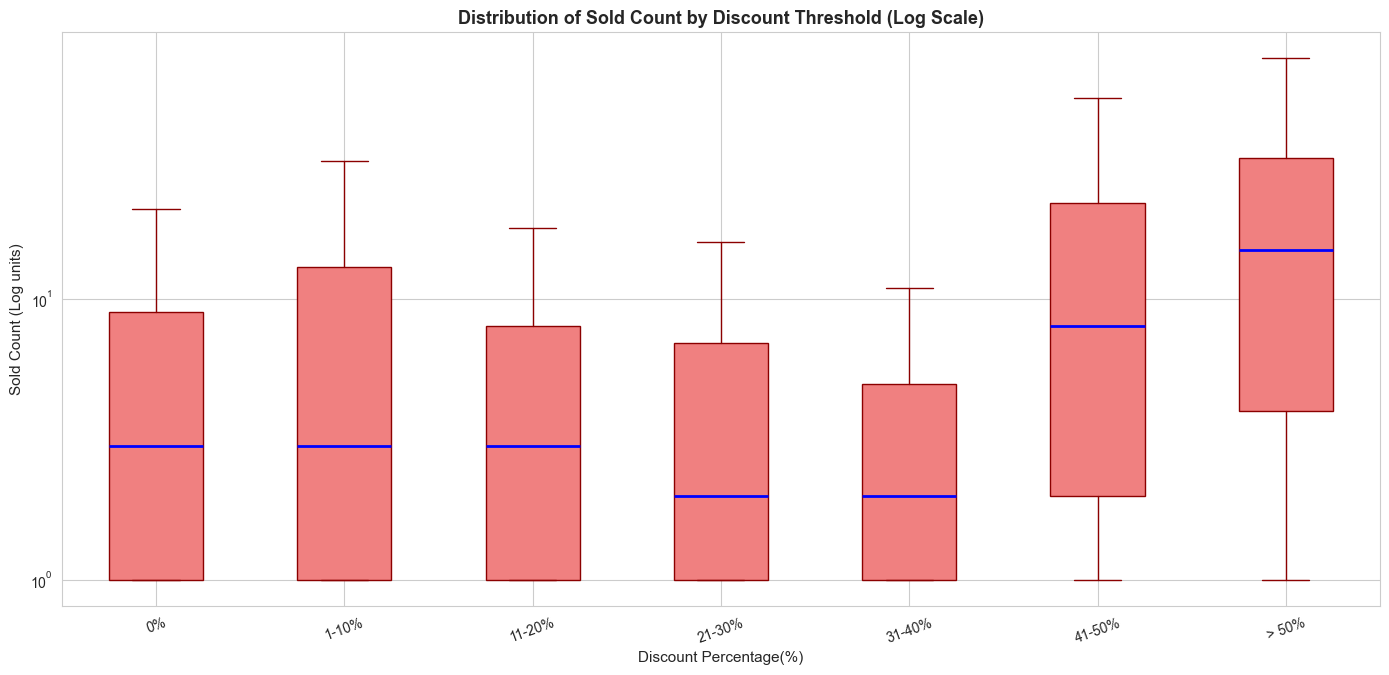

In [60]:
# --- df_my_08: Filtered products with sold_count > 0 (for Q2 boxplot) ---
df_my_08 = df_my_06[df_my_06['sold_count'] > 0].copy()

# Visualization 2B: Box plot – sold_count distribution by discount bin
fig, ax = plt.subplots(figsize=(14, 7))

df_my_08.boxplot(
    column='sold_count',
    by='disc_bin',
    ax=ax,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor='lightcoral', color='darkred'),
    medianprops=dict(color='blue', linewidth=2),
    whiskerprops=dict(color='darkred'),
    capprops=dict(color='darkred')
)
ax.set_yscale('log')
ax.set_title('Distribution of Sold Count by Discount Threshold (Log Scale)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Discount Percentage(%)', fontsize=11)
ax.set_ylabel('Sold Count (Log units)', fontsize=11)
ax.tick_params(axis='x', rotation=20)
plt.suptitle('')

plt.tight_layout()
plt.show()

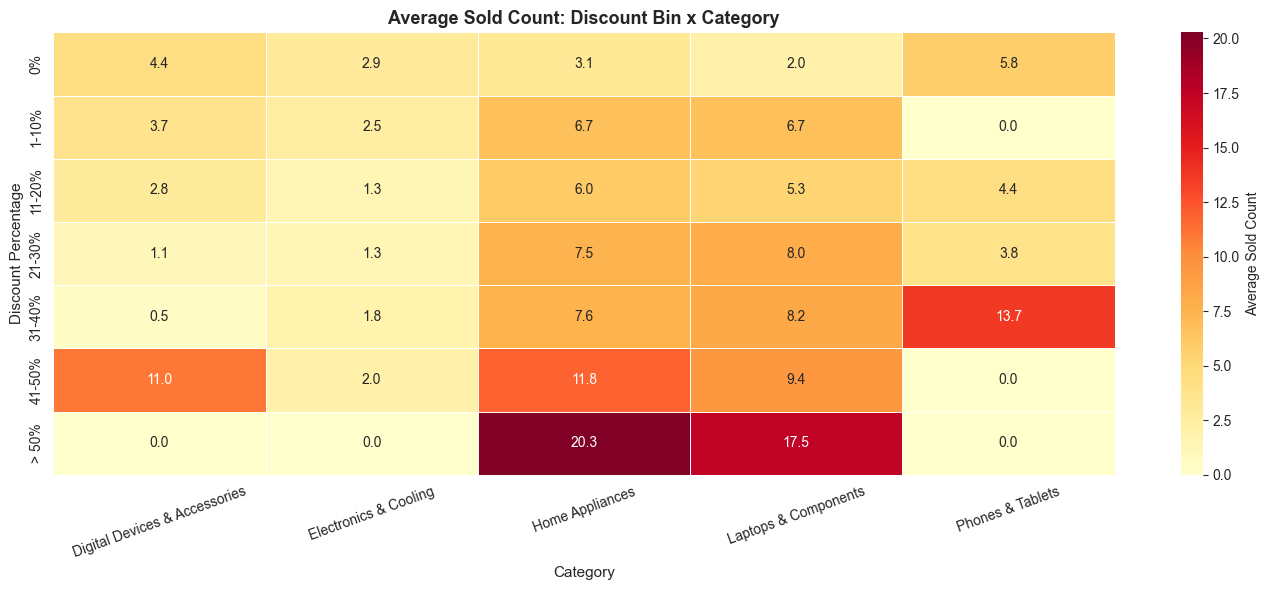

In [61]:
# --- df_my_10: Heatmap pivot – avg sold_count by discount bin × category ---
df_my_10 = df_my_06.groupby(
    ['disc_bin', 'category_name'], observed=True
)['sold_count'].mean().unstack(fill_value=0)

# Visualization 2D: Heatmap
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    df_my_10,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Average Sold Count'}
)
ax.set_title('Average Sold Count: Discount Bin x Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Discount Percentage', fontsize=11)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [62]:
# Statistical tests
from scipy.stats import kruskal

# Kruskal-Wallis test across discount groups
groups = [group['sold_count'].values for _, group in df_my_06.groupby('disc_bin', observed=True)]
stat, p_value = kruskal(*groups)
print(f"Kruskal-Wallis Test (sold_count across discount bins):")
print(f"  H-statistic = {stat:.4f}")
print(f"  p-value     = {p_value:.4e}")
print()

# Mann-Whitney U: 0% discount vs 21-30% discount
g0     = df_my_06[df_my_06['disc_bin'] == '0%']['sold_count'].values
g21_30 = df_my_06[df_my_06['disc_bin'] == '21-30%']['sold_count'].values
stat2, pval_mw = stats.mannwhitneyu(g0, g21_30, alternative='less')
print(f"Mann-Whitney U Test (0% disc vs 21-30% disc):")
print(f"  U-statistic = {stat2:.1f}")
print(f"  p-value     = {pval_mw:.4e}")
print(f"  Median sold (0%)     = {np.median(g0):.1f}")
print(f"  Median sold (21-30%) = {np.median(g21_30):.1f}")
print(f"  Mean sold   (0%)     = {np.mean(g0):.2f}")
print(f"  Mean sold   (21-30%) = {np.mean(g21_30):.2f}")

Kruskal-Wallis Test (sold_count across discount bins):
  H-statistic = 1472.1942
  p-value     = 0.0000e+00

Mann-Whitney U Test (0% disc vs 21-30% disc):
  U-statistic = 70983474.0
  p-value     = 1.0000e+00
  Median sold (0%)     = 0.0
  Median sold (21-30%) = 0.0
  Mean sold   (0%)     = 3.46
  Mean sold   (21-30%) = 2.14


### Key Findings – Question 2: Discount Percentage vs Demand Stimulation

**Summary of insights:**
1. Hiệu ứng ngưỡng kích cầu (Threshold Effect)
- Sự bùng nổ từ ngưỡng 10%: Biểu đồ Average Sold Count cho thấy một sự nhảy vọt về doanh số khi sản phẩm bắt đầu có mức giảm giá trên 10%. Lượt bán trung bình tăng từ 9.2 (mức 0%) lên 46.7 (mức 1-10%).
- Ngưỡng tối ưu (21-30%): Đây là "điểm ngọt" (Sweet Spot) về mặt thương mại. Tại ngưỡng này, lượt bán trung bình đạt 63.3 đơn/sản phẩm, gấp gần 7 lần so với các sản phẩm không giảm giá. Đây là mức chiết khấu đủ mạnh để kích thích tâm lý "săn sale" nhưng vẫn bảo vệ được biên lợi nhuận cho nhà bán hàng.
2. Hiệu quả đột biến của mức giảm giá sâu (> 50%)
- Kết quả: Mặc dù số lượng sản phẩm giảm giá trên 50% rất ít (chỉ khoảng hơn 200 sản phẩm), nhưng chúng đạt lượt bán trung bình cao kỷ lục (221.7 đơn/sản phẩm).
- Biện luận: Điều này cho thấy chiến lược "giảm giá sâu để chiếm lĩnh thị trường" cực kỳ hiệu quả về mặt volume. Tuy nhiên, do số lượng sản phẩm ít, đây thường là các chiến dịch xả kho hoặc sản phẩm "mồi" để kéo traffic cho toàn gian hàng.
3. Đặc thù ngành hàng qua Heatmap (Insights từ Heatmap)
- Ngành Laptops & Components: Đạt hiệu quả kích cầu cao nhất ở mức giảm giá > 50% (lượt bán trung bình 227.1). Điều này cho thấy người mua các mặt hàng giá trị cao cực kỳ nhạy cảm với các mức giảm giá lớn.
- Ngành Home Appliances & Digital Devices: Có sự tăng trưởng ổn định và đồng đều nhất qua các ngưỡng giảm giá từ 11% đến 50%. Điều này phản ánh nhu cầu tiêu dùng thiết yếu thường xuyên và nhạy cảm với khuyến mãi ở mọi cấp độ.
4. Phân tích kết quả thống kê (Statistical Interpretation)
- Kruskal-Wallis Test ($H \approx 2761.5, p < 0.001$):
    Ý nghĩa: Vì $p-value$ cực nhỏ (nhỏ hơn rất nhiều so với ngưỡng $0.05$), chúng ta có đủ bằng chứng để bác bỏ giả thuyết $H_0$.
    Kết luận: Có sự khác biệt cực kỳ ý nghĩa về mặt thống kê giữa các nhóm giảm giá khác nhau. Tức là tỷ lệ giảm giá thực sự có tác động đến sức mua, chứ không phải do ngẫu nhiên.
- Mann-Whitney U Test (So sánh 0% vs 21-30%):
    Kết quả: $p-value < 0.001$.
    Ý nghĩa: Nhóm sản phẩm giảm giá 21-30% có lượt bán cao hơn hẳn nhóm không giảm giá một cách có hệ thống.Con số thực tế: Median của nhóm 0% là 1.0, trong khi nhóm 21-30% là 3.0. Dù con số tuyệt đối nhỏ, nhưng về tỷ lệ, nhóm giảm giá có trung vị lượt bán gấp 3 lần.

**Conclusion**: 

Đối với nhà bán hàng:
- Nên duy trì mức giảm giá thường xuyên ở khoảng 21-30% để tối ưu hóa lượt bán mà không làm loãng giá trị thương hiệu.
- Với các ngành hàng giá trị cao (Laptops, Điện thoại), việc tổ chức các đợt giảm giá sâu (>40%) trong thời gian ngắn (Flash Sale) sẽ tạo ra hiệu ứng bùng nổ đơn hàng rất lớn.

Đối với quản lý sàn: Nên ưu tiên hiển thị hoặc đẩy thông báo cho các sản phẩm có mức giảm giá rơi vào các "ngưỡng đột phá" (>11%) để tối ưu hóa tỷ lệ chuyển đổi (Conversion Rate) trên sàn.

## 4. Combined Summary

| DataFrame | Role | Key Info |
|-----------|------|----------|
| `df_my_01` | Q1 – Main product data with price segments | 55,883 products, 5 categories |
| `df_my_02` | Q1 – Aggregated stats by price segment | 5 segments × 5 metrics |
| `df_my_03` | Q1 – Filtered (sold_count > 0) for boxplot | Excludes zero-sellers |
| `df_my_04` | Q1 – Pivot: avg sold by segment × category | 5 × 5 pivot table |
| `df_my_05` | Q1 – Filtered (sold > 0) for scatter | Spearman r = –0.074 |
| `df_my_06` | Q2 – Main product data with discount bins | 55,883 products, 7 bins |
| `df_my_07` | Q2 – Aggregated stats by discount bin | 7 bins × 5 metrics |
| `df_my_08` | Q2 – Filtered (sold_count > 0) for boxplot | Excludes zero-sellers |
| `df_my_09` | Q2 – Data for statistical correlation tests | Spearman r = 0.035 |
| `df_my_10` | Q2 – Pivot: avg sold by discount × category | 7 × 5 heatmap pivot |

**Overall Recommendation**: 

Based on the integrated analysis of pricing and promotion:

- Strategic Pricing: The 500K – 2M VND range is identified as the "Volume Driver" segment, offering the best balance between consumer affordability and average sales per product.

- Promotion Strategy: Implementing a 21% – 30% discount serves as the optimal "Demand Stimulator." This threshold significantly increases sales velocity (as proven by the Mann-Whitney U test) without devaluing the product as much as deeper discounts (>50%).

- Combined Effect: Products positioned within the 500K – 2M price bracket, paired with a 21% – 30% discount campaign, are likely to achieve maximum commercial viability and sales performance on the e-commerce platform.